# Assignment 5 - Clustering and Customer Segmentation (Unsupervised Learning)

- **Course:** MBAI 5310G: AI Programming - Ontario Tech University
- **Business:** BankWise Retail Banking Company
- **Dataset:** BankWise Credit Card Offer Acceptance Dataset  
- **Method:** K-means clustering

In this notebook we use unsupervised learning (K-means clustering) to discover hidden customer groups in BankWise's banking data, then interpret those groups to support marketing decisions. The work is organised under the seven assignment tasks and follows the Week 5 workflow.

## Task 1: Understand the Business Problem

Customer segmentation is an **unsupervised learning** problem: there is no target variable to predict. Instead of predicting a known label (such as whether a customer accepts an offer), we use customer features to discover hidden groups of similar customers.

**1. What is the main business problem?**  
BankWise, a mid-sized retail bank, currently sends the same credit-card offers to a broad list of customers. This leads to low acceptance rates, wasted marketing spend, and extra load on branch and call-centre teams. The bank needs to understand the natural groups within its customer base so that outreach can be targeted instead of uniform.

**2. Why is customer segmentation useful for this business?**  
Segmentation groups customers by shared behaviour (balances, transaction activity, tenure, branch usage, complaints). Once these groups are known, BankWise can match the right offer and channel to the right group, focus its limited marketing budget where conversion is most likely, and treat high-value or at-risk customers differently from low-engagement ones.

**3. What marketing decisions could be improved by discovering customer groups?**  
- Which offer type (cashback, travel rewards, low-interest, balance-transfer) to present to each group.  
- Which channel (mobile app, email, SMS, phone, branch) suits each group.  
- Where to focus retention effort versus low-cost digital outreach.  
- How to prioritise campaigns under a fixed budget by targeting the most responsive and most valuable segments.

**Business question:** *Can we discover meaningful customer groups that help BankWise design better, more targeted marketing strategies?*

## Task 2: Prepare the Dataset

In [1]:
# Import the libraries used throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

### Load the dataset
We load the BankWise dataset into Python using pandas and display the first five rows.

In [2]:
# Load the CSV dataset
df = pd.read_csv("bankwise_credit_card_offer_acceptance_dataset.csv")

# Display the first five rows
df.head()

,Customer_ID,Age,Income_Level,Account_Tenure_Years,Average_Monthly_Balance,Monthly_Transactions,Digital_Banking_Usage,Credit_Score_Band,Existing_Loan,Has_Savings_Account,Previous_Campaign_Response,Service_Complaints_6M,Branch_Visits_6M,Marketing_Channel,Offer_Type,Accepted_Offer
0,BW0001,48.0,High,10.2,692.64,25,High,Good,No,No,No Response,1,6,Phone,Low Interest,No
1,BW0002,41.0,Low,0.8,2972.25,12,Low,Fair,No,Yes,No Response,1,0,Mobile App,Cashback,No
2,BW0003,55.0,High,2.0,6072.03,16,Low,Excellent,No,No,No Response,0,5,SMS,Balance Transfer,No
3,BW0004,33.0,Medium,11.2,4663.60,40,Medium,Excellent,Yes,No,Clicked,2,8,Phone,Cashback,No
4,BW0005,25.0,Medium,17.2,4843.28,43,Medium,Fair,No,Yes,No Response,1,5,Branch,Cashback,No


### Inspect the dataset
We check the number of rows and columns, the column names, data types, missing values, and basic descriptive statistics before applying machine learning.

In [3]:
# Number of rows and columns
df.shape

(302, 16)

In [4]:
# Column names
df.columns

Index(['Customer_ID', 'Age', 'Income_Level', 'Account_Tenure_Years',
       'Average_Monthly_Balance', 'Monthly_Transactions',
       'Digital_Banking_Usage', 'Credit_Score_Band', 'Existing_Loan',
       'Has_Savings_Account', 'Previous_Campaign_Response',
       'Service_Complaints_6M', 'Branch_Visits_6M', 'Marketing_Channel',
       'Offer_Type', 'Accepted_Offer'],
      dtype='str')

In [5]:
# Data types and general information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 302 non-null    str    
 1   Age                         301 non-null    float64
 2   Income_Level                301 non-null    str    
 3   Account_Tenure_Years        302 non-null    float64
 4   Average_Monthly_Balance     300 non-null    float64
 5   Monthly_Transactions        302 non-null    int64  
 6   Digital_Banking_Usage       300 non-null    str    
 7   Credit_Score_Band           301 non-null    str    
 8   Existing_Loan               302 non-null    str    
 9   Has_Savings_Account         302 non-null    str    
 10  Previous_Campaign_Response  301 non-null    str    
 11  Service_Complaints_6M       302 non-null    int64  
 12  Branch_Visits_6M            302 non-null    int64  
 13  Marketing_Channel           302 non-null    st

In [6]:
# Missing values per column
df.isnull().sum()

Customer_ID                   0
Age                           1
Income_Level                  1
Account_Tenure_Years          0
Average_Monthly_Balance       2
Monthly_Transactions          0
Digital_Banking_Usage         2
Credit_Score_Band             1
Existing_Loan                 0
Has_Savings_Account           0
Previous_Campaign_Response    1
Service_Complaints_6M         0
Branch_Visits_6M              0
Marketing_Channel             0
Offer_Type                    0
Accepted_Offer                0
dtype: int64

In [7]:
# Duplicate rows
df.duplicated().sum()

np.int64(2)

In [8]:
# Summary statistics for numerical columns
df.describe()

,Age,Account_Tenure_Years,Average_Monthly_Balance,Monthly_Transactions,Service_Complaints_6M,Branch_Visits_6M
count,301.000000,302.000000,300.000000,302.000000,302.000000,302.000000
mean,41.096346,5.697351,5075.637333,27.947020,0.546358,2.930464
std,10.785825,5.104359,5611.345534,11.046437,0.883310,2.212573
min,18.000000,0.100000,269.240000,1.000000,0.000000,0.000000
25%,33.000000,1.925000,2072.135000,20.000000,0.000000,1.000000
50%,42.000000,4.000000,3514.580000,28.000000,0.000000,3.000000
75%,48.000000,8.775000,5817.725000,36.000000,1.000000,4.000000
max,73.000000,20.000000,62906.060000,60.000000,4.000000,10.000000


**Note on the target variable.** The dataset contains an `Accepted_Offer` column, but for this assignment we are *not* predicting it. Customer segmentation is unsupervised, so we use only the customer feature columns (X) and no target (y).

### Clean the dataset
We create a working copy, tidy the column names, then check for and remove duplicate rows and handle missing values. Clean data is important because K-means works better when the dataset is consistent.

In [9]:
# Create a copy of the original dataset for cleaning
df_clean = df.copy()
print("Original dataset shape:", df_clean.shape)

Original dataset shape: (302, 16)


In [10]:
# Clean column names by removing any extra spaces
df_clean.columns = df_clean.columns.str.strip()
df_clean.columns

Index(['Customer_ID', 'Age', 'Income_Level', 'Account_Tenure_Years',
       'Average_Monthly_Balance', 'Monthly_Transactions',
       'Digital_Banking_Usage', 'Credit_Score_Band', 'Existing_Loan',
       'Has_Savings_Account', 'Previous_Campaign_Response',
       'Service_Complaints_6M', 'Branch_Visits_6M', 'Marketing_Channel',
       'Offer_Type', 'Accepted_Offer'],
      dtype='str')

In [11]:
# Check duplicate rows
duplicate_count = df_clean.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 2


In [12]:
# Remove duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (300, 16)


For the numerical features we fill any missing values using the **median** of each column. The median is robust to the skew in balance and avoids dropping customers.

In [13]:
# Numerical columns used for clustering
numerical_columns = [
    "Age",
    "Account_Tenure_Years",
    "Average_Monthly_Balance",
    "Monthly_Transactions",
    "Service_Complaints_6M",
    "Branch_Visits_6M",
]

# Fill missing values in numerical columns with the median
for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Check missing values again
df_clean[numerical_columns].isnull().sum()

Age                        0
Account_Tenure_Years       0
Average_Monthly_Balance    0
Monthly_Transactions       0
Service_Complaints_6M      0
Branch_Visits_6M           0
dtype: int64

### Select the numerical features for clustering
For clustering we do **not** use `Customer_ID` (it is only an identifier) or the categorical/target columns. We select the six numerical behavioural and profile features that describe how customers bank with BankWise.

In [14]:
# Select the numerical features for clustering
X = df_clean[numerical_columns]

# Display the selected features
X.head()

,Age,Account_Tenure_Years,Average_Monthly_Balance,Monthly_Transactions,Service_Complaints_6M,Branch_Visits_6M
0,48.0,10.2,692.64,25,1,6
1,41.0,0.8,2972.25,12,1,0
2,55.0,2.0,6072.03,16,0,5
3,33.0,11.2,4663.60,40,2,8
4,25.0,17.2,4843.28,43,1,5


In [15]:
# Confirm the shape and that there are no missing values
print("Selected features shape:", X.shape)
print("Missing values in X:", int(X.isnull().sum().sum()))

Selected features shape: (300, 6)
Missing values in X: 0


### Scale the features
K-means is based on distance, so features with larger values (for example balance in thousands) can dominate features with small values (for example complaints from 0-4). `StandardScaler` puts every feature on a mean-0, unit-variance scale so each contributes fairly.

In [16]:
# Create the scaler and scale the selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_columns)
X_scaled_df.head()

,Age,Account_Tenure_Years,Average_Monthly_Balance,Monthly_Transactions,Service_Complaints_6M,Branch_Visits_6M
0,0.646520,0.882967,-0.781945,-0.275058,0.509253,1.386163
1,-0.004027,-0.961590,-0.374962,-1.455175,0.509253,-1.322951
2,1.297066,-0.726115,0.178447,-1.092062,-0.622420,0.934644
3,-0.747509,1.079197,-0.073003,1.086615,1.640925,2.289202
4,-1.490991,2.256574,-0.040924,1.358950,0.509253,0.934644


In [17]:
# Check the mean (≈0) and standard deviation (≈1) after scaling
print("Mean after scaling:")
print(X_scaled_df.mean().round(3))
print("\nStandard deviation after scaling:")
print(X_scaled_df.std().round(3))

Mean after scaling:
Age                       -0.0
Account_Tenure_Years       0.0
Average_Monthly_Balance    0.0
Monthly_Transactions      -0.0
Service_Complaints_6M      0.0
Branch_Visits_6M          -0.0
dtype: float64

Standard deviation after scaling:
Age                        1.002
Account_Tenure_Years       1.002
Average_Monthly_Balance    1.002
Monthly_Transactions       1.002
Service_Complaints_6M      1.002
Branch_Visits_6M           1.002
dtype: float64


## Task 3: Apply K-means Clustering

### Use the Elbow Method to choose the number of clusters
The Elbow Method compares different values of K and measures how spread out the points are within each cluster (the **inertia**). We look for the point where the decrease becomes much slower i.e. the "elbow".

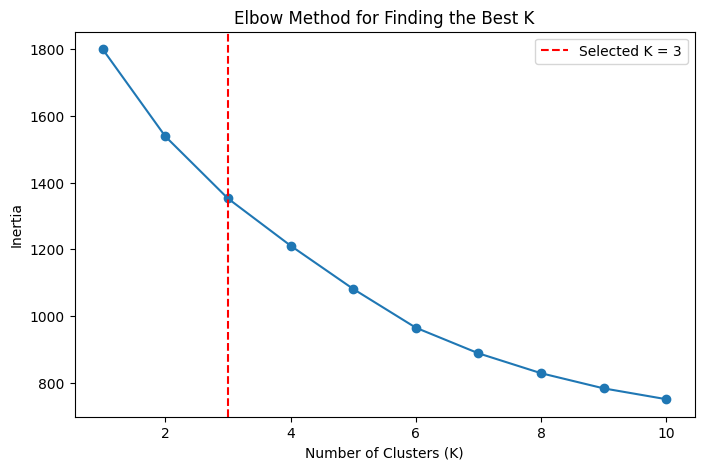

In [18]:
# Test different values of K and record the inertia
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.axvline(x=3, color="red", linestyle="--", label="Selected K = 3")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.legend()
plt.show()

In [19]:
# Display the inertia value for each K
elbow_results = pd.DataFrame({"K": list(K_range), "Inertia": np.round(inertia, 1)})
elbow_results

,K,Inertia
0,1,1800.0
1,2,1538.5
2,3,1352.3
3,4,1210.8
4,5,1080.9
5,6,964.7
6,7,887.9
7,8,828.1
8,9,782.7
9,10,750.2


### Confirm the choice with the silhouette score
The elbow can be hard to read when the bend is gentle, so we also check the **silhouette score** for each K (higher = better-separated clusters). This gives an objective way to compare candidate values such as K = 3 and K = 4.

In [20]:
# Silhouette score for each K (needs at least 2 clusters)
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

silhouette_results = pd.DataFrame({"K": list(range(2, 11)), "Silhouette_Score": np.round(sil_scores, 3)})
silhouette_results

,K,Silhouette_Score
0,2,0.145
1,3,0.158
2,4,0.147
3,5,0.158
4,6,0.166
5,7,0.171
6,8,0.160
7,9,0.175
8,10,0.155


### Why K = 3 was selected (and not K = 4)
Two pieces of evidence point to **K = 3**:

- **Elbow Method.** The inertia drops most sharply up to K = 3 (the largest single drop, ≈186) and then flattens, so the elbow sits at K = 3.
- **Silhouette score.** K = 3 scores higher (≈0.158) than K = 4 (≈0.147). Moving from 3 to 4 clusters actually *worsens* the separation as it splits the data into an extra group without making the clusters cleaner.

K = 3 is therefore both the statistically stronger choice and the more practical one: it produces three clear, easy-to-act-on customer segments. We train the final model with **K = 3**.

### Train the final K-means model
We train K-means with K = 3 on the scaled features. Each customer is assigned to one cluster based on similarity.

In [21]:
# Create and train the K-means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Display the first 10 cluster labels
cluster_labels[:10]

array([1, 0, 0, 2, 1, 1, 2, 0, 1, 1], dtype=int32)

### Add the cluster labels back to the dataset
We add the cluster numbers to a copy of the cleaned dataset. These numbers (0, 1, 2) show which segment each customer belongs to; we give them business names in Task 4.

In [22]:
# Add cluster labels to a copy of the cleaned dataset
df_clustered = df_clean.copy()
df_clustered["Cluster"] = cluster_labels

# Display the first five rows
df_clustered.head()

,Customer_ID,Age,Income_Level,Account_Tenure_Years,Average_Monthly_Balance,Monthly_Transactions,Digital_Banking_Usage,Credit_Score_Band,Existing_Loan,Has_Savings_Account,Previous_Campaign_Response,Service_Complaints_6M,Branch_Visits_6M,Marketing_Channel,Offer_Type,Accepted_Offer,Cluster
0,BW0001,48.0,High,10.2,692.64,25,High,Good,No,No,No Response,1,6,Phone,Low Interest,No,1
1,BW0002,41.0,Low,0.8,2972.25,12,Low,Fair,No,Yes,No Response,1,0,Mobile App,Cashback,No,0
2,BW0003,55.0,High,2.0,6072.03,16,Low,Excellent,No,No,No Response,0,5,SMS,Balance Transfer,No,0
3,BW0004,33.0,Medium,11.2,4663.60,40,Medium,Excellent,Yes,No,Clicked,2,8,Phone,Cashback,No,2
4,BW0005,25.0,Medium,17.2,4843.28,43,Medium,Fair,No,Yes,No Response,1,5,Branch,Cashback,No,1


In [23]:
# Check how many customers are in each cluster
df_clustered["Cluster"].value_counts().sort_index()

Cluster
0    168
1     94
2     38
Name: count, dtype: int64

## Task 4: Analyze and Interpret the Clusters

### Analyze the cluster summary
We calculate the average value of each feature for each cluster and add the number of customers. This shows how the groups differ.

In [24]:
# Average value of each feature for each cluster
cluster_summary = df_clustered.groupby("Cluster")[numerical_columns].mean().round(2)

# Add the number of customers in each cluster
cluster_summary["Number_of_Customers"] = df_clustered["Cluster"].value_counts().sort_index()

cluster_summary

,Age,Account_Tenure_Years,Average_Monthly_Balance,Monthly_Transactions,Service_Complaints_6M,Branch_Visits_6M,Number_of_Customers
Cluster,,,,,,,
0,40.39,3.00,5383.66,23.30,0.31,2.77,168
1,42.89,10.33,3962.88,36.73,0.18,2.99,94
2,39.37,6.16,6441.75,27.39,2.53,3.47,38


### Interpret the customer segments
K-means gives cluster numbers without business meaning. We read the averages above and give each cluster a meaningful name. Following the Week 5 approach, we identify the most **active** group (highest monthly transactions), the highest-**value** group among the rest (highest average balance), and treat the remaining group as **low-engagement**.

In [25]:
# Identify clusters based on customer behaviour
summary = cluster_summary.copy()

# Most active group: highest monthly transactions
active_cluster = summary["Monthly_Transactions"].idxmax()

# Highest-value group among the remaining: highest average balance
remaining = summary.drop(index=active_cluster)
premium_cluster = remaining["Average_Monthly_Balance"].idxmax()

# The remaining cluster is treated as low engagement
low_engagement_cluster = summary.drop(index=[active_cluster, premium_cluster]).index[0]

# Business names for the clusters
segment_names = {
    active_cluster: "Active Engaged Customers",
    premium_cluster: "High-Value Premium Customers",
    low_engagement_cluster: "Low-Engagement Customers",
}

# Add segment names to the dataset
df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_names)
df_clustered[["Customer_ID"] + numerical_columns + ["Cluster", "Segment_Name"]].head(10)

,Customer_ID,Age,Account_Tenure_Years,Average_Monthly_Balance,Monthly_Transactions,Service_Complaints_6M,Branch_Visits_6M,Cluster,Segment_Name
0,BW0001,48.0,10.2,692.64,25,1,6,1,Active Engaged Customers
1,BW0002,41.0,0.8,2972.25,12,1,0,0,Low-Engagement Customers
2,BW0003,55.0,2.0,6072.03,16,0,5,0,Low-Engagement Customers
3,BW0004,33.0,11.2,4663.60,40,2,8,2,High-Value Premium Customers
4,BW0005,25.0,17.2,4843.28,43,1,5,1,Active Engaged Customers
5,BW0006,52.0,8.1,4408.88,34,0,4,1,Active Engaged Customers
6,BW0007,55.0,1.2,2633.44,35,2,6,2,High-Value Premium Customers
7,BW0008,42.0,4.6,4077.88,30,0,0,0,Low-Engagement Customers
8,BW0009,42.0,6.2,1391.39,34,0,2,1,Active Engaged Customers
9,BW0010,46.0,10.3,7676.40,45,0,3,1,Active Engaged Customers


In [26]:
# Interpretation table for each segment
segment_interpretation = pd.DataFrame({
    "Cluster": list(segment_names.keys()),
    "Segment Name": list(segment_names.values()),
    "Business Interpretation": [
        "Long banking relationship and the highest transaction activity; frequent, loyal users.",
        "Highest average balance (strong purchasing power) but also the most service complaints.",
        "Largest group: moderate balance, shorter tenure and lower transaction activity; mostly passive.",
    ],
    "Possible Business Strategy": [
        "Loyalty rewards and cashback offers tied to their regular activity.",
        "Premium and travel-rewards offers, plus service recovery to address complaints first.",
        "Reactivation offers (low-interest / balance-transfer) and digital engagement nudges.",
    ],
})
segment_interpretation

,Cluster,Segment Name,Business Interpretation,Possible Business Strategy
0,1,Active Engaged Customers,Long banking relationship and the highest tran...,Loyalty rewards and cashback offers tied to th...
1,2,High-Value Premium Customers,Highest average balance (strong purchasing pow...,"Premium and travel-rewards offers, plus servic..."
2,0,Low-Engagement Customers,"Largest group: moderate balance, shorter tenur...",Reactivation offers (low-interest / balance-tr...


In [27]:
# Number of customers in each named segment
df_clustered["Segment_Name"].value_counts()

Segment_Name
Low-Engagement Customers        168
Active Engaged Customers         94
High-Value Premium Customers     38
Name: count, dtype: int64

**Answers to the Task 4 questions:**

1. **How many segments did we find?** Three customer segments.

2. **Main characteristics of each segment** (from the summary table):
   - **Active Engaged Customers** - longest tenure (≈10 years) and the highest monthly transactions (≈37), with very few complaints. Loyal, habitual users.
   - **High-Value Premium Customers** - the highest average balance (≈6,400) and strong purchasing power, but also the highest complaint rate (≈2.5). Valuable yet not fully satisfied.
   - **Low-Engagement Customers** - the largest group, with moderate balances, shorter tenure (≈3 years) and lower transaction activity. Mostly passive.              

3. **How are the segments different?** They separate mainly along *activity* (transactions, tenure), *value* (balance), and *satisfaction* (complaints). One group is high-activity, one is high-value, and one is low-engagement.

4. **Most valuable segment.** The **High-Value Premium Customers** carry the largest balances and the greatest purchasing potential, making them the most valuable to grow, provided their service issues are resolved.

5. **Segment needing the most marketing attention.** The **Low-Engagement Customers** are the largest group but contribute little activity; they need reactivation campaigns to lift engagement. (The Premium group also needs *service* attention because of its high complaint rate.)

## Task 5: Visualize the Clusters

We create more than two visualizations: the Elbow plot (Task 3), a two-feature scatter plot, and a PCA projection. Each is followed by a short interpretation.

### Visualization 1 - Clusters using two features
A scatter plot of **Average Monthly Balance** against **Monthly Transactions** shows how the groups separate on value and activity. Each colour is one cluster.

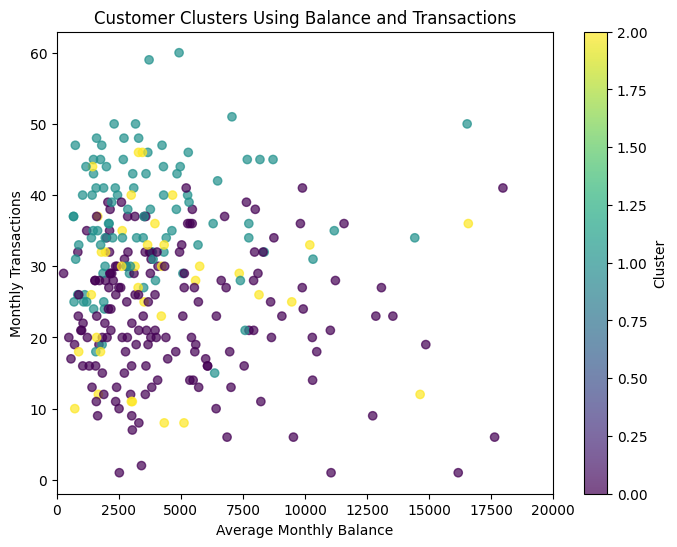

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_clustered["Average_Monthly_Balance"],
    df_clustered["Monthly_Transactions"],
    c=df_clustered["Cluster"],
    alpha=0.7,
)
plt.xlabel("Average Monthly Balance")
plt.ylabel("Monthly Transactions")
plt.title("Customer Clusters Using Balance and Transactions")
plt.xlim(0, 20000)  # clip extreme balance outliers for readability
plt.colorbar(label="Cluster")
plt.show()

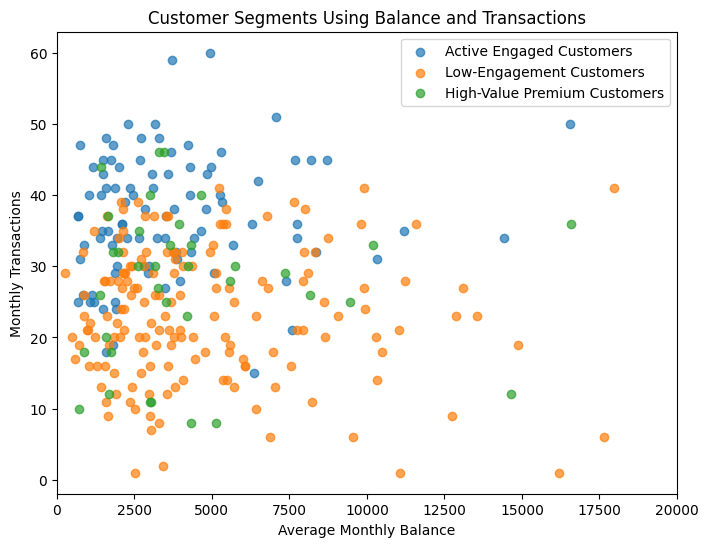

In [29]:
# Same view, labelled with the business segment names
plt.figure(figsize=(8, 6))
for segment in df_clustered["Segment_Name"].unique():
    seg = df_clustered[df_clustered["Segment_Name"] == segment]
    plt.scatter(seg["Average_Monthly_Balance"], seg["Monthly_Transactions"],
                label=segment, alpha=0.7)
plt.xlabel("Average Monthly Balance")
plt.ylabel("Monthly Transactions")
plt.title("Customer Segments Using Balance and Transactions")
plt.xlim(0, 20000)
plt.legend()
plt.show()

*Interpretation:* The Active Engaged Customers sit high on the transactions axis, the High-Value Premium Customers stretch to the right on the balance axis, and the Low-Engagement Customers cluster lower on both. The groups overlap somewhat because customer behaviour is continuous, but the centres are clearly different - the two features capture real differences between segments.

### Visualization 2 - Clusters with PCA
**PCA (Principal Component Analysis)** reduces the six features into two components so we can view the clusters in 2-D. PCA does **not** create the clusters; K-means does. PCA only helps us visualise them.

In [30]:
# Apply PCA to reduce the scaled features into two components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clustered["PCA1"] = X_pca[:, 0]
df_clustered["PCA2"] = X_pca[:, 1]

# How much information each component explains
explained_variance = pca.explained_variance_ratio_
print("Explained variance by PCA1:", round(explained_variance[0], 3))
print("Explained variance by PCA2:", round(explained_variance[1], 3))
print("Total explained variance:", round(explained_variance.sum(), 3))

Explained variance by PCA1: 0.231
Explained variance by PCA2: 0.19
Total explained variance: 0.421


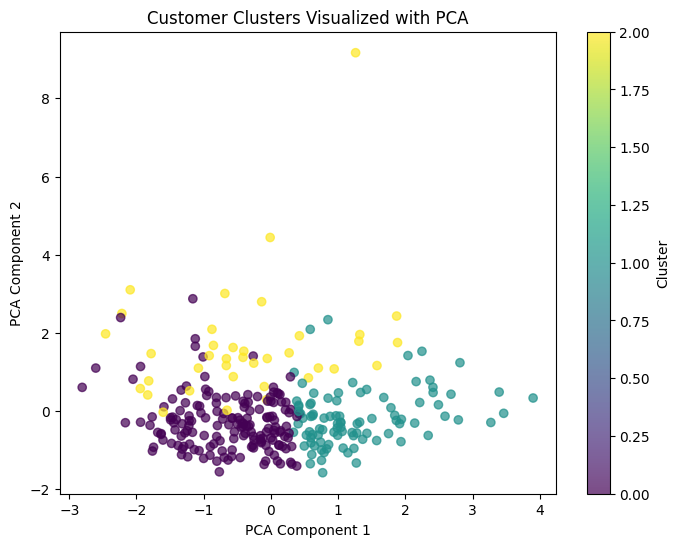

In [31]:
# Visualize the clusters using the two PCA components
plt.figure(figsize=(8, 6))
plt.scatter(df_clustered["PCA1"], df_clustered["PCA2"], c=df_clustered["Cluster"], alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Clusters Visualized with PCA")
plt.colorbar(label="Cluster")
plt.show()

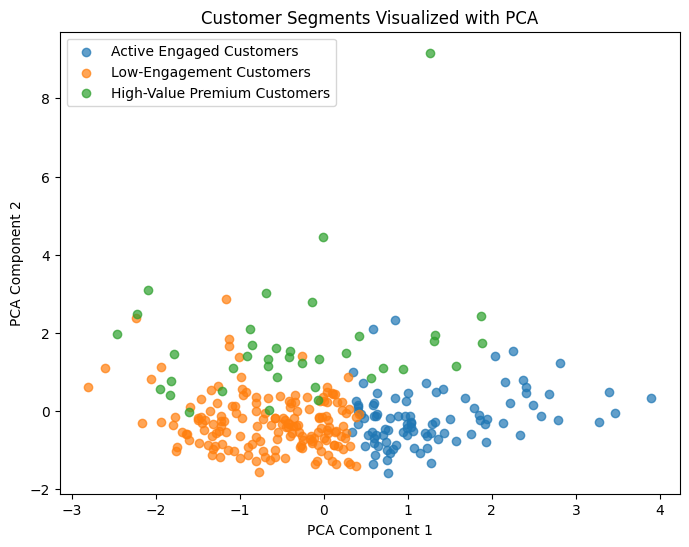

In [32]:
# Same PCA view, labelled with business segment names
plt.figure(figsize=(8, 6))
for segment in df_clustered["Segment_Name"].unique():
    seg = df_clustered[df_clustered["Segment_Name"] == segment]
    plt.scatter(seg["PCA1"], seg["PCA2"], label=segment, alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments Visualized with PCA")
plt.legend()
plt.show()

*Interpretation:* The first two components together explain about 42% of the variation in the six features. In the PCA space the Active Engaged Customers appear on the right, the High-Value Premium Customers sit in the upper area, and the Low-Engagement Customers fall in the lower-left. The three segments occupy different regions, which confirms that K-means found meaningful structure even though some overlap remains.

## Task 6: Business Interpretation

In [33]:
# Business interpretation of the clusters
business_interpretation = pd.DataFrame({
    "Customer Segment": [
        "Active Engaged Customers",
        "High-Value Premium Customers",
        "Low-Engagement Customers",
    ],
    "Business Meaning": [
        "Loyal, frequent users with long tenure and high transaction activity.",
        "High balances and strong purchasing power, but currently dissatisfied (high complaints).",
        "Largest, mostly passive group with lower activity and shorter tenure.",
    ],
    "Recommended Strategy": [
        "Loyalty rewards and activity-based cashback offers; mobile app and email.",
        "Premium and travel-rewards offers with VIP service; resolve complaints first.",
        "Reactivation: low-interest / balance-transfer offers and digital engagement nudges.",
    ],
    "Business Goal": [
        "Maintain loyalty and strengthen long-term relationships.",
        "Grow wallet share and protect valuable customers from churn.",
        "Increase engagement and move passive customers toward active use.",
    ],
})
business_interpretation

,Customer Segment,Business Meaning,Recommended Strategy,Business Goal
0,Active Engaged Customers,"Loyal, frequent users with long tenure and hig...",Loyalty rewards and activity-based cashback of...,Maintain loyalty and strengthen long-term rela...
1,High-Value Premium Customers,"High balances and strong purchasing power, but...",Premium and travel-rewards offers with VIP ser...,Grow wallet share and protect valuable custome...
2,Low-Engagement Customers,"Largest, mostly passive group with lower activ...",Reactivation: low-interest / balance-transfer ...,Increase engagement and move passive customers...


In [34]:
# Average feature values for each business segment
business_segment_summary = df_clustered.groupby("Segment_Name")[numerical_columns].mean().round(2)
business_segment_summary

,Age,Account_Tenure_Years,Average_Monthly_Balance,Monthly_Transactions,Service_Complaints_6M,Branch_Visits_6M
Segment_Name,,,,,,
Active Engaged Customers,42.89,10.33,3962.88,36.73,0.18,2.99
High-Value Premium Customers,39.37,6.16,6441.75,27.39,2.53,3.47
Low-Engagement Customers,40.39,3.00,5383.66,23.30,0.31,2.77


**Answers to the Task 6 questions:**

1. **What patterns did we discover?** BankWise's customers fall into three behavioural groups that differ on activity, value, and satisfaction: active loyal users, high-value but dissatisfied customers, and a large low-engagement majority.

2. **How can the business use these segments?** Replace one-size-fits-all campaigns with segment-specific targeting to match offer type and channel to each group, prioritise campaigns by segment value, and route dissatisfied high-value customers to service recovery rather than sales.

3. **Suggested marketing strategy per segment** (see the table above): loyalty and cashback for Active Engaged Customers; premium/travel-rewards plus complaint resolution for High-Value Premium Customers; reactivation and low-interest offers for Low-Engagement Customers.

4. **How does this improve decision-making?** Targeting the right offer to the right group should raise acceptance rates and lower cost-per-contact by avoiding wasted outreach. It also lets BankWise protect valuable customers proactively and measure campaign performance segment by segment, turning one blunt campaign into several focused, testable ones.

## Task 7: Limitations and Responsible AI Reflection

In [35]:
# Limitations of K-means clustering
kmeans_limitations = pd.DataFrame({
    "Limitation": [
        "Need to choose K",
        "Sensitive to outliers",
        "Assumes simple cluster shapes",
        "Depends on selected features",
        "Cluster labels need interpretation",
    ],
    "Explanation": [
        "The number of clusters must be selected before training the model.",
        "Unusual customers (e.g. very high balances) can shift the cluster centres.",
        "K-means works best when clusters are roughly circular and well separated.",
        "Different feature choices can produce different segments.",
        "Cluster numbers 0, 1, 2 have no business meaning on their own.",
    ],
    "Business Impact": [
        "Different K values may lead to different customer segments.",
        "Outliers may create misleading customer groups.",
        "Some real customer patterns may not be captured accurately.",
        "Leaving out categorical data (income band, credit score) may hide patterns.",
        "Human judgment is needed to name segments and design strategies.",
    ],
})
kmeans_limitations

,Limitation,Explanation,Business Impact
0,Need to choose K,The number of clusters must be selected before...,Different K values may lead to different custo...
1,Sensitive to outliers,Unusual customers (e.g. very high balances) ca...,Outliers may create misleading customer groups.
2,Assumes simple cluster shapes,K-means works best when clusters are roughly c...,Some real customer patterns may not be capture...
3,Depends on selected features,Different feature choices can produce differen...,"Leaving out categorical data (income band, cre..."
4,Cluster labels need interpretation,"Cluster numbers 0, 1, 2 have no business meani...",Human judgment is needed to name segments and ...


In [36]:
# Responsible AI reflection
responsible_ai_reflection = pd.DataFrame({
    "Responsible AI Issue": ["Fairness", "Bias", "Privacy", "Interpretability", "Human Judgment"],
    "Explanation": [
        "Segments should not be used to unfairly exclude or disadvantage customers.",
        "Clusters may reflect bias in the data or in features tied to income or credit.",
        "Customer banking data must be handled carefully and protected.",
        "Cluster numbers need clear business interpretation, not absolute trust.",
        "Humans should review results before making real customer decisions.",
    ],
    "Responsible Action": [
        "Use segments to improve service, not to deny products to groups.",
        "Review the features for unfair patterns before acting on the segments.",
        "Use only data that is necessary and appropriate for the task.",
        "Explain each segment in plain business language.",
        "Combine model results with expert knowledge and ethical judgment.",
    ],
})
responsible_ai_reflection

,Responsible AI Issue,Explanation,Responsible Action
0,Fairness,Segments should not be used to unfairly exclud...,"Use segments to improve service, not to deny p..."
1,Bias,Clusters may reflect bias in the data or in fe...,Review the features for unfair patterns before...
2,Privacy,Customer banking data must be handled carefull...,Use only data that is necessary and appropriat...
3,Interpretability,Cluster numbers need clear business interpreta...,Explain each segment in plain business language.
4,Human Judgment,Humans should review results before making rea...,Combine model results with expert knowledge an...


**Answers to the Task 7 questions:**

1. **One limitation of the dataset / model.** The data is synthetic and educational, so the segments reflect generated patterns rather than real BankWise customers. We also used only six numerical features; including the categorical fields (income band, credit score, channel) could change the groupings.

2. **Why K-means does not always produce perfect segments.** K-means assumes roughly circular, similarly sized clusters and needs K fixed in advance. Real customer behaviour is continuous and overlapping (visible in the scatter and PCA plots), so the boundaries are fuzzy. Results also depend on scaling, on the chosen features, and on outliers.

3. **Possible bias or unfair decision from unreviewed use.** If BankWise acted on these clusters automatically, low-balance or low-engagement customers could be systematically denied good offers, and features tied to income or credit can encode existing social and economic inequalities — quietly steering products away from already-underserved groups.

4. **Why human judgment is still needed.** The model only repeats patterns in past data; it cannot see fairness concerns, recent life changes, customer intent, or regulatory context. Segments should *inform*, not replace human marketing decisions, and any targeting rule built on them should be reviewed for fairness before reaching real customers.